# Household Income vs. B2C E-Commerce Growth

## The Question

Is Malaysia's B2C e-commerce growth being driven by rising household purchasing power, or is it decoupled from it?

Notebook 01 found that B2C e-commerce grew slower than overall retail trade (6.6% vs. 8.0% CAGR, 2021–2024), a result that ran against the expected "digital shift" narrative. This notebook investigates whether household income trends explain that gap: did purchasing power itself grow slowly over the same window, or did it grow while B2C failed to capture a proportional share?

## The Answer

Household income and B2C e-commerce income happen to share an identical 6.6% CAGR over their respective windows — but that match is a coincidence of the two different windows being compared (income 2020–2024, e-commerce 2021–2024), not evidence the two move together (see Confidence & Caveats below). What the data actually shows is a difference in *timing*, not direction: both series grew throughout, but income growth was front-loaded (fastest between 2020 and 2022, decelerating through 2024), while B2C growth was back-loaded (nearly flat between 2021 and 2022, accelerating sharply through 2023–2024). This suggests B2C e-commerce is not simply tracking household purchasing power; it appears to be decoupling from it, growing on its own timeline and, by 2023–2024, faster than the rate at which income itself was expanding.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

income = pd.read_csv('../data/raw/hh_income.csv')
ecommerce = pd.read_csv('../data/processed/ecommerce_income.csv')
income

,date,income_mean,income_median
0,1970-01-01,264,166
1,1974-01-01,362,227
2,1976-01-01,505,308
3,1979-01-01,678,429
4,1984-01-01,1098,719
5,1987-01-01,1083,738
6,1989-01-01,1169,816
7,1992-01-01,1566,1077
8,1995-01-01,2020,1377
9,1997-01-01,2606,1724


In [2]:
# House chart style v2: MBB-style chart conventions:
# gray for context series, one or two accent colors for what the title is
# actually about, direct end-of-line/bar labels instead of a legend box.
ACCENT_1 = '#2a78d6'   # primary accent, the series the title is about
ACCENT_2 = '#eb6834'   # secondary accent; used only for genuine two-way comparisons
                        # or a title that names two co-equal findings
GRAY = '#9a9a95'        # de-emphasized / context series, same family, faded out
INK, INK_SECONDARY, INK_MUTED = '#0b0b0b', '#52514e', '#898781'
GRID, SURFACE = '#ececea', '#fcfcfb'

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'text.color': INK,
    'axes.edgecolor': '#c3c2b7',
    'axes.labelcolor': INK_SECONDARY,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.axisbelow': True,
    'axes.grid.axis': 'y',
    'grid.color': GRID,
    'grid.linewidth': 0.7,
    'xtick.color': INK_MUTED,
    'ytick.color': INK_MUTED,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'legend.frameon': False,
})

def add_source(fig, text):
    """Small muted source/classification footnote, exhibit style."""
    fig.text(0.01, -0.04, text, ha='left', va='top', fontsize=8.5,
              color=INK_MUTED, style='italic', transform=fig.transFigure)

def end_label(ax, x, y, text, color, weight='semibold', va='center', offset=8):
    """Direct label at a line's endpoint, replacing a legend box."""
    ax.annotate(text, xy=(x, y), xytext=(offset, 0), textcoords='offset points',
                 va=va, ha='left', fontsize=10.5, fontweight=weight, color=color)


## Comparing growth rates across mismatched time windows

`hh_income.csv` is a biennial survey; within our project window it only has three data points (2020, 2022, 2024), with no 2021 or 2023. B2C e-commerce data starts in 2021, not 2020. Rather than force these onto a shared set of years (which would discard real data from the richer e-commerce series), each series' CAGR is calculated over its own available range, then the *rates* are compared, the same approach used for the B2C-vs-retail comparison in notebook 01.

This means the two CAGR figures below cover different windows (income: 2020–2024, B2C: 2021–2024), which is a real limitation, not a rounding detail, addressed explicitly in the caveats at the end of this notebook.

In [3]:
# Household income CAGR, 2020-2024 (4 years)
income_start = income[income['date'] == '2020-01-01']['income_mean'].values[0]
income_end = income[income['date'] == '2024-01-01']['income_mean'].values[0]
income_cagr = ((income_end / income_start) ** (1/4) - 1) * 100

# B2C e-commerce CAGR, 2021-2024 (3 years): recomputed here so this notebook runs standalone
b2c_start = ecommerce[ecommerce['year'] == 2021]['b2c_rm_billion'].values[0]
b2c_end = ecommerce[ecommerce['year'] == 2024]['b2c_rm_billion'].values[0]
b2c_cagr = ((b2c_end / b2c_start) ** (1/3) - 1) * 100

print(f"Household income CAGR (2020-2024): {income_cagr:.1f}%")
print(f"B2C e-commerce CAGR (2021-2024): {b2c_cagr:.1f}%")

Household income CAGR (2020-2024): 6.6%
B2C e-commerce CAGR (2021-2024): 6.6%


## Visualizing the two trends side by side

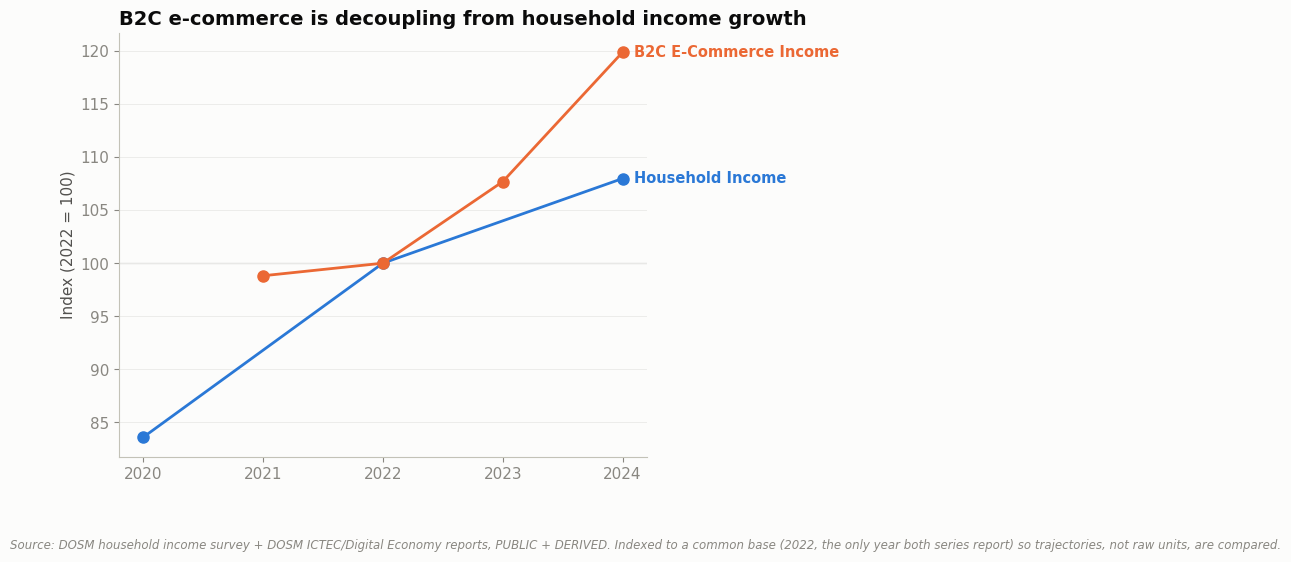

In [4]:
# Index both series to 100 at 2022, the one year both series report; 
# so growth *trajectories* are comparable on a single axis (a shared axis on
# raw units would be meaningless: RM per household vs. RM billion, a dual-axis
# chart would invent a correlation that isn't in the data).
income_idx = income[income['date'].isin(['2020-01-01', '2022-01-01', '2024-01-01'])].copy()
income_idx['year'] = [2020, 2022, 2024]
income_base = income_idx.loc[income_idx['year'] == 2022, 'income_mean'].values[0]
income_idx['index'] = income_idx['income_mean'] / income_base * 100

b2c_idx = ecommerce[ecommerce['year'] >= 2021][['year', 'b2c_rm_billion']].copy()
b2c_base = b2c_idx.loc[b2c_idx['year'] == 2022, 'b2c_rm_billion'].values[0]
b2c_idx['index'] = b2c_idx['b2c_rm_billion'] / b2c_base * 100

fig, ax = plt.subplots(figsize=(9.5, 5.5))
ax.plot(income_idx['year'], income_idx['index'], marker='o', markersize=8,
        linewidth=2, color=ACCENT_1)
ax.plot(b2c_idx['year'], b2c_idx['index'], marker='o', markersize=8,
        linewidth=2, color=ACCENT_2)
ax.axhline(100, color=INK_MUTED, linewidth=0.8, zorder=0)

end_label(ax, income_idx['year'].iloc[-1], income_idx['index'].iloc[-1], 'Household Income', ACCENT_1, weight='bold')
end_label(ax, b2c_idx['year'].iloc[-1], b2c_idx['index'].iloc[-1], 'B2C E-Commerce Income', ACCENT_2, weight='bold')

ax.set_title('B2C e-commerce is decoupling from household income growth', loc='left')
ax.set_ylabel('Index (2022 = 100)')
ax.set_xlabel('')
ax.set_xticks([2020, 2021, 2022, 2023, 2024])
fig.subplots_adjust(right=0.68)

add_source(ax.figure, 'Source: DOSM household income survey + DOSM ICTEC/Digital Economy reports, '
                       'PUBLIC + DERIVED. Indexed to a common base (2022, the only year both series report) '
                       'so trajectories, not raw units, are compared.')
plt.show()


## Strategic Recommendation

- **B2C growth appears increasingly driven by channel shift, not just rising income.** Since e-commerce accelerated even as income growth was slowing, a meaningful share of that growth likely reflects existing consumer spending moving online, rather than a wealthier consumer base simply spending more overall. Businesses evaluating B2C e-commerce should treat this as evidence of genuine digital adoption, not merely a byproduct of economic growth.
- **The 2023–2024 acceleration is the period to watch closely**, since it's where B2C growth most clearly outpaces income; any business tracking this market should prioritize recent-period data over long-run averages, which would understate the current momentum.

## Confidence & Caveats

- **Mismatched time windows.** Household income CAGR covers 2020–2024 (4 years); B2C e-commerce CAGR covers 2021–2024 (3 years), since e-commerce segment data isn't available for 2020. The two CAGR figures are not measuring the exact same period, and their apparent match (6.6% vs. 6.6%) should be read as coincidental rather than evidence of a direct relationship.
- **Sparse income data.** The "front-loaded vs. back-loaded" trajectory read on household income rests on only 3 data points (2020, 2022, 2024), since the underlying survey is biennial. This is a read on the shape formed by 3 points, not a dense trend line, a different biennial pattern could produce a different-looking curve.
- **Descriptive, not causal.** This notebook shows that B2C growth and income growth diverged in trajectory; it does not identify *why*. No data here explains what specifically drove the divergence (e.g., changing consumer habits, platform-side supply growth, pricing shifts); that would require a different dataset entirely.

## Why Is This Happening? (Context)

*Qualitative, secondary-sourced context on the mechanism behind this notebook's decoupling finding; kept separate from the PUBLIC/DERIVED DOSM figures above. Full citations in [`DATA_DICTIONARY.md`](../DATA_DICTIONARY.md).*

B2C e-commerce growing independently of household income is best explained by a parallel shift in how people pay, not just what they earn. Malaysia's digital payment infrastructure scaled dramatically over this window: e-wallet usage rose from 63% of Malaysians to 88% between 2022 and 2023 alone, DuitNow QR merchant registrations grew 47% year-on-year to 2.6 million in 2025, and total national digital transactions reached 8.44 billion in 2025. Each of these lowers the friction of buying online regardless of income, removing cash-handling and bank-transfer barriers that previously constrained online spending more than earnings did.

**Source:** [PayNet, "8.44bil transactions processed in 2025 as digital payments become Malaysians' preferred way to pay"](https://www.paynet.my/about-us/media-centre/press-release/8-44-billion-transactions-processed-in-2025-as-digital-payments-become-malaysians-preferred-way-to-pay.html).